# Exercise 3

This notebook is organized around the revised Problem 3 scope: motivate the RBM choice, describe the activation-function choice used in the implemented models, benchmark periodic TFIM training on a small exactly solvable chain at `h = 0.5`, `1.0`, and `1.5`, then set up larger periodic-system studies on a length-32 TFIM chain, a `5x5` TFIM lattice, and a `5x5` square-lattice `J_1-J_2` model.

The GHZ section is also revised: the target is the `h = 0` Ising-chain ground state on the periodic length-32 TFIM chain, so the appendix studies the same system class as the main TFIM workflow rather than a separate toy lattice.


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from exercise_report_helper import (
    add_report_figure_context,
    build_output_manifest,
    ensure_report_output_dir,
    plot_architecture_summary,
    plot_energy_benchmark,
    plot_entropy_scan,
    plot_lattice_graph,
    plot_training_history,
    save_report_figure,
    save_report_table,
)
from nqs import Chain1D, SquareLattice, observables
from nqs.workflows import run_ghz_bonus_workflow, run_hamiltonian_system_size_sweep, run_random_architecture_study, run_vmc_experiment


In [3]:
selected_model = {'model_name': 'RBM', 'model_kwargs': {'alpha': 2}}

small_training_config = {
    'n_iter': 256,
    'n_samples': 256,
    'n_discard_per_chain': 32,
    'n_chains': 16,
    'callback_every': 2,
}

large_training_config = {
    'n_iter': 70,
    'n_samples': 384,
    'n_discard_per_chain': 32,
    'n_chains': 16,
    'callback_every': 2,
}

exercise_output_dir = ensure_report_output_dir('exercise_3')
exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_3')

In [4]:
def _tail_slope(series: pd.Series) -> float:
    values = np.asarray(series, dtype=float)
    if values.size < 2:
        return float('nan')
    x_values = np.arange(values.size, dtype=float)
    return float(np.polyfit(x_values, values, 1)[0])


def _safe_float(value: object) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return float('nan')


def training_diagnostics_row(
    label: str,
    result: dict[str, object],
    *,
    field_h: float | None = None,
    J1: float | None = None,
    J2: float | None = None,
) -> dict[str, float | int | str]:
    history_df = result['history_df'].copy()
    entropy_history = history_df.dropna(subset=['renyi2_entropy']).copy()
    if entropy_history.empty:
        initial_logged_entropy = float('nan')
        max_logged_entropy = float('nan')
        final_logged_entropy = float('nan')
    else:
        initial_logged_entropy = float(entropy_history['renyi2_entropy'].iloc[0])
        max_logged_entropy = float(entropy_history['renyi2_entropy'].max())
        final_logged_entropy = float(entropy_history['renyi2_entropy'].iloc[-1])

    tail = history_df.tail(min(5, len(history_df)))
    exact = result.get('exact', {})
    n_sites = int(result['system']['hilbert'].size)
    j1_over_j2 = float(J1) / float(J2) if J1 is not None and J2 not in (None, 0.0) else float('nan')
    exact_half_partition_renyi2 = _safe_float(exact.get('half_partition_renyi2'))
    return {
        'sweep_label': label,
        'field_h': float(field_h) if field_h is not None else float('nan'),
        'J1': float(J1) if J1 is not None else float('nan'),
        'J2': float(J2) if J2 is not None else float('nan'),
        'J1_over_J2': j1_over_j2,
        'n_sites': n_sites,
        'initial_energy': float(history_df['energy'].iloc[0]),
        'best_logged_energy': float(history_df['energy'].min()),
        'final_energy': float(result['final_energy']),
        'exact_ground_energy': _safe_float(exact.get('ground_energy')),
        'energy_error': float(result['energy_error']),
        'energy_error_per_site': float(result['energy_error']) / n_sites,
        'tail_energy_std': float(tail['energy'].std(ddof=0)) if len(tail) > 1 else 0.0,
        'tail_energy_slope': _tail_slope(tail['energy']),
        'exact_half_partition_renyi2': exact_half_partition_renyi2,
        'initial_logged_renyi2': initial_logged_entropy,
        'max_logged_renyi2': max_logged_entropy,
        'final_logged_renyi2': final_logged_entropy,
        'final_half_partition_renyi2': float(result['final_entropy']),
        'half_partition_renyi2_gap': float(result['final_entropy']) - exact_half_partition_renyi2,
    }


## Report Setup And Reproducibility

The notebook is set up for three layers of analysis:

- `3(a-b)`: architecture choice plus VMC-method description
- `3(c)`: exact-benchmarked periodic `4x1` TFIM runs at `h = 0.5`, `1.0`, and `1.5`
- `3(d)`: larger periodic-system runs on a length-32 TFIM chain, a `5x5` TFIM lattice, and a `5x5` square-lattice `J_1-J_2` model
- `3(e-f)`: GHZ appendix on the periodic length-32 `h = 0` TFIM chain plus the entanglement-tail appendix

All stochastic steps use deterministic seeds embedded in the notebook, and the export cell writes regenerated tables and figures to `demos/report_outputs/exercise_3/`. Re-running the notebook top-to-bottom refreshes the report artifacts in place.


In [5]:
exercise_3_run_context = pd.DataFrame([
    {'item': 'selected_model', 'value': f"{selected_model['model_name']} {selected_model['model_kwargs']}"},
    {'item': 'problem_3_scope', 'value': '3(a-b) architecture + VMC method, 3(c) periodic 4x1 TFIM benchmark, 3(d) periodic 32x1 TFIM + 5x5 TFIM + 5x5 J1-J2, 3(e-f) appendix'},
    {'item': 'small_systems', 'value': '4x1 periodic TFIM at h = 0.5, 1.0, and 1.5'},
    {'item': 'large_systems', 'value': '32x1 periodic TFIM at h = 1.0 and 1.5; 5x5 periodic TFIM at h = 3.0 and 4.0; 5x5 periodic J1-J2 at J1/J2 = 1.8 and 2.2'},
    {'item': 'ghz_system', 'value': '32x1 periodic TFIM at h = 0.0'},
    {'item': 'small_training_config', 'value': str(small_training_config)},
    {'item': 'large_training_config', 'value': str(large_training_config)},
    {'item': 'seed_schedule', 'value': 'Small benchmark uses seeds 0, 1, 2; larger sweep uses base seed 0 with per-sweep offsets; GHZ appendix uses seed 0'},
    {'item': 'backend', 'value': 'Project VMC workflow with JAX x64 enabled in-notebook'},
    {'item': 'output_dir', 'value': str(exercise_output_dir)},
])
exercise_3_run_context


,item,value
0,selected_model,RBM {'alpha': 2}
1,problem_3_scope,"3(a-b) architecture + VMC method, 3(c) periodi..."
2,small_systems,"4x1 periodic TFIM at h = 0.5, 1.0, and 1.5"
3,large_systems,32x1 periodic TFIM at h = 1.0 and 1.5; 5x5 per...
4,ghz_system,32x1 periodic TFIM at h = 0.0
5,small_training_config,"{'n_iter': 60, 'n_samples': 256, 'n_discard_pe..."
6,large_training_config,"{'n_iter': 70, 'n_samples': 384, 'n_discard_pe..."
7,seed_schedule,"Small benchmark uses seeds 0, 1, 2; larger swe..."
8,backend,Project VMC workflow with JAX x64 enabled in-n...
9,output_dir,C:\Users\balin\PycharmProjects\NQS\Balint\demo...


## 3/a Architecture Choice And Activation-Function Choice

Exercise 2 already compared RBM, FFNN, and CNN on the retained `4x4` random-state entanglement study. That remains the evidence base for the ansatz choice: before worrying about optimizer details, we want a model family that already shows a clear capacity to represent entangled states under the same sampler and observable workflow.

The retained Exercise 2 summary below shows that the RBM family was the only one to produce order-one half-partition Renyi-2 while still keeping `valid_entropy_fraction = 1.0` across sampled subsystem sizes. FFNN and CNN remained close to zero on the same periodic `4x4` study. I therefore keep `RBM(alpha=2)` for the training study because it is the higher-capacity member of the only family that clearly displayed useful entanglement capacity in the prior benchmark.

The activation-function choice in the implemented models is also deliberate. The FFNN and CNN classes use `tanh` as their default hidden activation, and all model families pass the phase channel through `phi_theta(sigma) = pi * tanh(p_theta(sigma))`. That smooth bounded nonlinearity keeps the phase output in a controlled range and avoids unbounded phase excursions at initialization. The RBM does not rely on stacked hidden activations in the same way as the FFNN or CNN, but it still shares the same bounded phase map at the output, so the comparison keeps a consistent phase parameterization across architectures.


In [6]:
exercise_3_architecture_reference = run_random_architecture_study(
    architecture_configs={
        'RBM alpha=1': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
            'initialization': {'parameter_scale': 0.25, 'phase_scale': 0.0, 'label': 'real-amplitude scale=0.25'},
        },
        'RBM alpha=2': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 2},
            'initialization': {'parameter_scale': 0.25, 'phase_scale': 0.0, 'label': 'real-amplitude scale=0.25'},
        },
        'FFNN width=12': {
            'model_name': 'FFNN',
            'model_kwargs': {'hidden_dims': (12,)},
            'initialization': {'parameter_scale': 0.25, 'phase_scale': 0.0, 'label': 'real-amplitude scale=0.25'},
        },
        'CNN channels=6': {
            'model_name': 'CNN',
            'model_kwargs': {'channels': (6,), 'kernel_size': (2, 2)},
            'initialization': {'parameter_scale': 0.25, 'phase_scale': 0.0, 'label': 'real-amplitude scale=0.25'},
        },
    },
    seeds=(0,),
    lattice_shape=(4, 4),
    pbc=True,
    hamiltonian='tfim',
    h=2.5,
    n_samples=32,
    n_discard_per_chain=2,
    n_chains=4,
    entropy_n_independent_runs=1,
)
model_order = ['RBM alpha=1', 'RBM alpha=2', 'FFNN width=12', 'CNN channels=6']
exercise_3_architecture_evidence = (
    exercise_3_architecture_reference['summary_table'].loc[
        exercise_3_architecture_reference['summary_table']['model'].isin(model_order)
    , [
        'model',
        'parameter_count',
        'half_partition_sampled_renyi2',
        'half_partition_sampled_std',
        'valid_entropy_fraction',
    ]]
    .assign(model=lambda df: pd.Categorical(df['model'], categories=model_order, ordered=True))
    .sort_values('model')
    .assign(model=lambda df: df['model'].astype(str))
    .rename(columns={
        'parameter_count': 'parameter_count',
        'half_partition_sampled_renyi2': 'exercise_2_half_partition_sampled_renyi2',
        'half_partition_sampled_std': 'exercise_2_half_partition_sampled_std',
        'valid_entropy_fraction': 'exercise_2_valid_entropy_fraction',
    })
    .reset_index(drop=True)
)
exercise_3_architecture_evidence


,model,parameter_count,exercise_2_half_partition_sampled_renyi2,exercise_2_half_partition_sampled_std,exercise_2_valid_entropy_fraction
0,RBM alpha=1,576,0.130225,0.0,1.0
1,RBM alpha=2,1120,0.120776,0.0,1.0
2,FFNN width=12,230,0.000383,0.0,1.0
3,CNN channels=6,224,0.000460,0.0,1.0


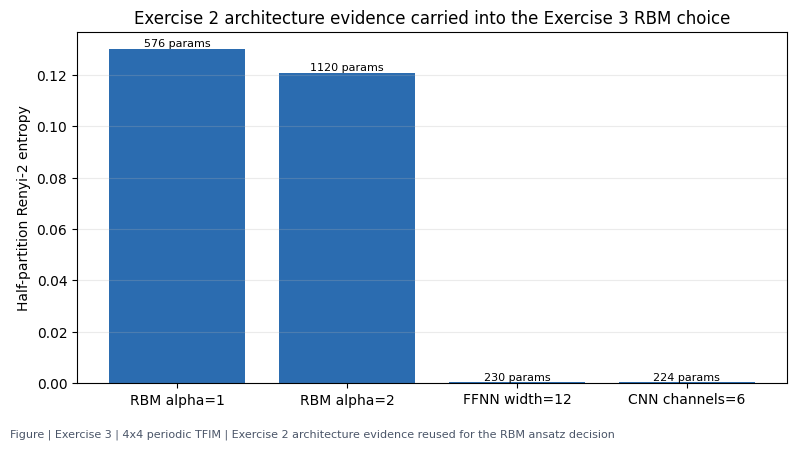

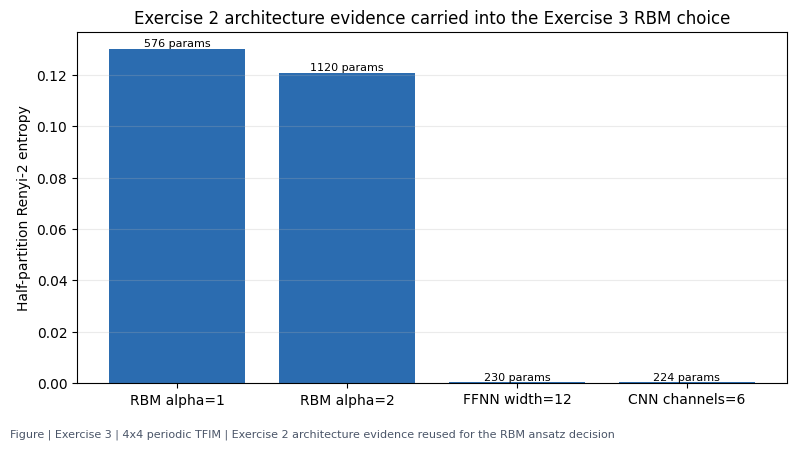

In [7]:
exercise_3_architecture_plot_table = exercise_3_architecture_evidence.rename(columns={
    'exercise_2_half_partition_sampled_renyi2': 'half_partition_renyi2',
    'exercise_2_half_partition_sampled_std': 'half_partition_std',
    'exercise_2_valid_entropy_fraction': 'valid_entropy_fraction',
})

architecture_summary_figure = plot_architecture_summary(
    exercise_3_architecture_plot_table,
    title='Exercise 2 architecture evidence carried into the Exercise 3 RBM choice',
)
add_report_figure_context(
    architecture_summary_figure,
    distinction='Figure',
    context='Exercise 3 | 4x4 periodic TFIM | Exercise 2 architecture evidence reused for the RBM ansatz decision',
)
architecture_summary_figure


In [8]:
exercise_3_architecture_decision = pd.DataFrame([
    {
        'criterion': 'Entanglement capacity on 4x4',
        'reading': 'RBM(alpha=1,2) gives order-one half-partition sampled Renyi-2 in Exercise 2, while FFNN and CNN stay near zero on the same budget.',
    },
    {
        'criterion': 'Estimator reliability',
        'reading': 'All retained Exercise 2 architectures kept valid_entropy_fraction = 1.0, so the RBM advantage is not caused by missing or failed entropy estimates.',
    },
    {
        'criterion': 'Final choice for Problem 3',
        'reading': 'RBM(alpha=2) keeps the RBM inductive bias from Exercise 2 while adding the higher-capacity member of that family for VMC training.',
    },
])
exercise_3_architecture_decision

,criterion,reading
0,Entanglement capacity on 4x4,"RBM(alpha=1,2) gives order-one half-partition ..."
1,Estimator reliability,All retained Exercise 2 architectures kept val...
2,Final choice for Problem 3,RBM(alpha=2) keeps the RBM inductive bias from...


## 3/b VMC Setup For The TFIM Ground-State Search

The variational objective is the energy of the neural quantum state,

$$
E_\theta = \frac{
    \langle \psi_\theta | H | \psi_\theta \rangle
}{
    \langle \psi_\theta | \psi_\theta \rangle
}.
$$

For Monte Carlo samples $\sigma \sim |\psi_\theta(\sigma)|^2$, the project workflow evaluates the local energy

$$
E_{\mathrm{loc}}(\sigma) = \sum_{\sigma'} H_{\sigma',\sigma} \frac{\psi_\theta(\sigma')}{\psi_\theta(\sigma)}.
$$

and uses the usual log-derivative VMC estimator with $O_\theta(\sigma) = \nabla_\theta \log \psi_\theta(\sigma)$,

$$
\nabla_\theta E_\theta = 2\,\mathrm{Re}\left[
    \langle O_\theta^* E_{\mathrm{loc}} \rangle
    -
    \langle O_\theta^* \rangle \langle E_{\mathrm{loc}} \rangle
\right].
$$

The project `MetropolisLocal` sampler supplies the samples, Adam performs the parameter updates, and the notebook records the half-partition Renyi-2 every two training steps so that energy convergence and entanglement evolution can be inspected together. Periodic boundary conditions are used throughout this notebook. The small `4x1` benchmark remains small enough for exact reconstruction of the trained variational state, while the larger periodic systems are set up to rely on the sampled route once exact reconstruction is no longer affordable.


In [9]:
exercise_3_vmc_context = pd.DataFrame([
    {'section': 'objective', 'item': 'training target', 'value': 'Minimize sampled variational energy E_theta of the chosen Hamiltonian'},
    {'section': 'estimator', 'item': 'local energy path', 'value': 'Connected configurations sigma-prime are generated by the operator helper, then E_loc(sigma) uses psi_theta(sigma-prime) / psi_theta(sigma)'},
    {'section': 'gradient', 'item': 'VMC estimator', 'value': 'Use the log-derivative covariance estimator with O_theta = grad_theta log psi_theta'},
    {'section': 'optimizer', 'item': 'parameter update', 'value': 'Adam with learning_rate = 1e-2 through the project Optax-backed VMC driver'},
    {'section': 'sampler', 'item': 'sampling budget', 'value': 'MetropolisLocal with 16 chains and 32 discard steps per chain'},
    {'section': 'boundary_conditions', 'item': 'lattice convention', 'value': 'Periodic boundary conditions are used for all Exercise 3 systems'},
    {'section': 'diagnostics', 'item': 'during training', 'value': 'Log energy every step and half-partition Renyi-2 every 2 steps'},
    {'section': 'diagnostics', 'item': 'after training', 'value': 'Benchmark against exact diagonalization on the periodic 4x1 TFIM chain and retain subsystem-size Renyi-2 scans for the trained states'},
    {'section': 'small benchmark', 'item': 'run budget', 'value': str(small_training_config)},
    {'section': 'larger sweep', 'item': 'run budget', 'value': str(large_training_config)},
])
exercise_3_vmc_context


,section,item,value
0,objective,training target,Minimize sampled variational energy E_theta of...
1,estimator,local energy path,Connected configurations sigma-prime are gener...
2,gradient,VMC estimator,Use the log-derivative covariance estimator wi...
3,optimizer,parameter update,Adam with learning_rate = 1e-2 through the pro...
4,sampler,sampling budget,MetropolisLocal with 16 chains and 32 discard ...
5,boundary_conditions,lattice convention,Periodic boundary conditions are used for all ...
6,diagnostics,during training,Log energy every step and half-partition Renyi...
7,diagnostics,after training,Benchmark against exact diagonalization on the...
8,small benchmark,run budget,"{'n_iter': 60, 'n_samples': 256, 'n_discard_pe..."
9,larger sweep,run budget,"{'n_iter': 70, 'n_samples': 384, 'n_discard_pe..."


## 3/c Small-System Benchmarks: Energy And Renyi-2 During Training

The exact benchmark keeps diagonalization cheap by using a periodic `4x1` TFIM chain. To answer Problem 3(c) directly, the notebook compares three field values under the same RBM and optimizer settings:

- `h = 0.5`: ferromagnetic regime
- `h = 1.0`: critical regime
- `h = 1.5`: paramagnetic regime

The question is whether the ordering of optimization difficulty and entanglement already separates these regimes on the smallest periodic chain for which an exact reference is still easy to retain.


In [10]:
exercise_3_small_ferromagnetic = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=True,
    hamiltonian='tfim',
    J=1.0,
    h=0.5,
    entropy_n_independent_runs=8,
    seed=0,
    **small_training_config,
)

exercise_3_small_critical = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=True,
    hamiltonian='tfim',
    J=1.0,
    h=1.0,
    entropy_n_independent_runs=8,
    seed=1,
    **small_training_config,
)

exercise_3_small_paramagnetic = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=True,
    hamiltonian='tfim',
    J=1.0,
    h=1.5,
    entropy_n_independent_runs=8,
    seed=2,
    **small_training_config,
)

exercise_3_small_summary = pd.DataFrame([
    {
        'sweep_label': 'TFIM 4x1, h=0.5',
        'field_h': 0.5,
        'exact_ground_energy': exercise_3_small_ferromagnetic['exact']['ground_energy'],
        'final_energy': exercise_3_small_ferromagnetic['final_energy'],
        'energy_error': exercise_3_small_ferromagnetic['energy_error'],
        'exact_half_partition_renyi2': exercise_3_small_ferromagnetic['exact']['half_partition_renyi2'],
        'final_half_partition_renyi2': exercise_3_small_ferromagnetic['final_entropy'],
        'half_partition_renyi2_gap': exercise_3_small_ferromagnetic['final_entropy'] - exercise_3_small_ferromagnetic['exact']['half_partition_renyi2'],
    },
    {
        'sweep_label': 'TFIM 4x1, h=1.0',
        'field_h': 1.0,
        'exact_ground_energy': exercise_3_small_critical['exact']['ground_energy'],
        'final_energy': exercise_3_small_critical['final_energy'],
        'energy_error': exercise_3_small_critical['energy_error'],
        'exact_half_partition_renyi2': exercise_3_small_critical['exact']['half_partition_renyi2'],
        'final_half_partition_renyi2': exercise_3_small_critical['final_entropy'],
        'half_partition_renyi2_gap': exercise_3_small_critical['final_entropy'] - exercise_3_small_critical['exact']['half_partition_renyi2'],
    },
    {
        'sweep_label': 'TFIM 4x1, h=1.5',
        'field_h': 1.5,
        'exact_ground_energy': exercise_3_small_paramagnetic['exact']['ground_energy'],
        'final_energy': exercise_3_small_paramagnetic['final_energy'],
        'energy_error': exercise_3_small_paramagnetic['energy_error'],
        'exact_half_partition_renyi2': exercise_3_small_paramagnetic['exact']['half_partition_renyi2'],
        'final_half_partition_renyi2': exercise_3_small_paramagnetic['final_entropy'],
        'half_partition_renyi2_gap': exercise_3_small_paramagnetic['final_entropy'] - exercise_3_small_paramagnetic['exact']['half_partition_renyi2'],
    },
]).round(6)

exercise_3_small_history = pd.concat([
    exercise_3_small_ferromagnetic['history_df'].assign(sweep_label='TFIM 4x1, h=0.5', field_h=0.5),
    exercise_3_small_critical['history_df'].assign(sweep_label='TFIM 4x1, h=1.0', field_h=1.0),
    exercise_3_small_paramagnetic['history_df'].assign(sweep_label='TFIM 4x1, h=1.5', field_h=1.5),
], ignore_index=True)

exercise_3_small_diagnostics = pd.DataFrame([
    training_diagnostics_row('TFIM 4x1, h=0.5', exercise_3_small_ferromagnetic, field_h=0.5),
    training_diagnostics_row('TFIM 4x1, h=1.0', exercise_3_small_critical, field_h=1.0),
    training_diagnostics_row('TFIM 4x1, h=1.5', exercise_3_small_paramagnetic, field_h=1.5),
]).round(6)

exercise_3_small_summary


,sweep_label,field_h,exact_ground_energy,final_energy,energy_error,exact_half_partition_renyi2,final_half_partition_renyi2,half_partition_renyi2_gap
0,"TFIM 4x1, h=0.5",0.5,-4.271558,-4.197760,0.073798,0.659281,0.078455,-0.580827
1,"TFIM 4x1, h=1.0",1.0,-5.226252,-5.223773,0.002479,0.386461,0.381652,-0.004808
2,"TFIM 4x1, h=1.5",1.5,-6.760009,-6.443930,0.316079,0.167198,0.059769,-0.107429


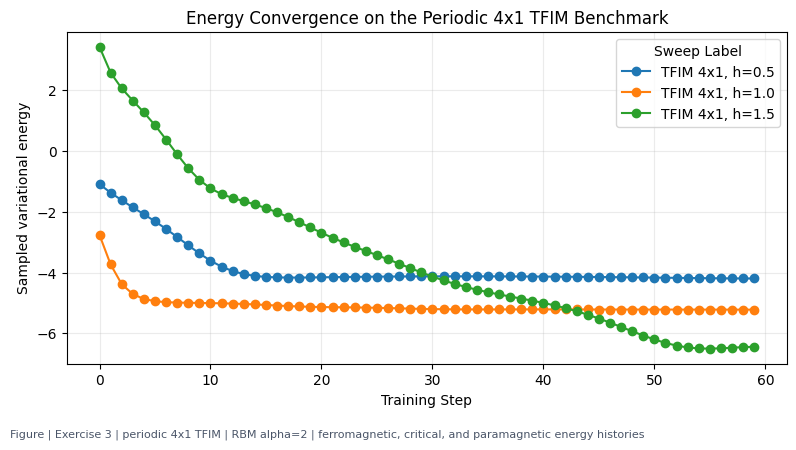

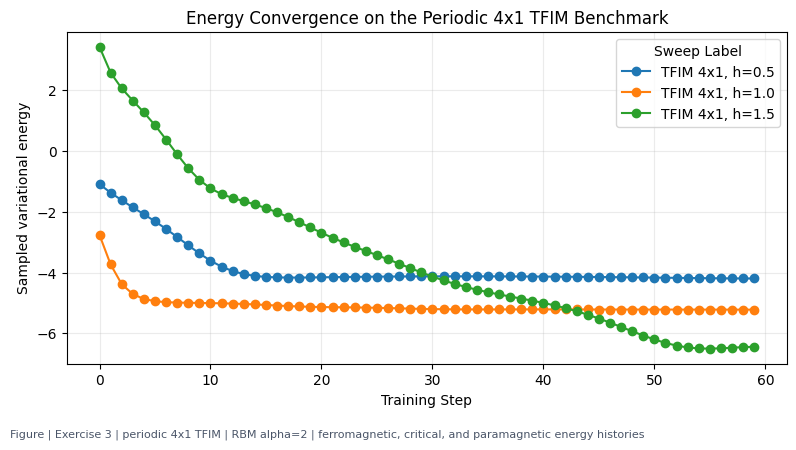

In [11]:
small_energy_figure = plot_training_history(
    exercise_3_small_history,
    'energy',
    line_column='sweep_label',
    title='Energy Convergence on the Periodic 4x1 TFIM Benchmark',
)
add_report_figure_context(
    small_energy_figure,
    distinction='Figure',
    context='Exercise 3 | periodic 4x1 TFIM | RBM alpha=2 | ferromagnetic, critical, and paramagnetic energy histories',
)
small_energy_figure


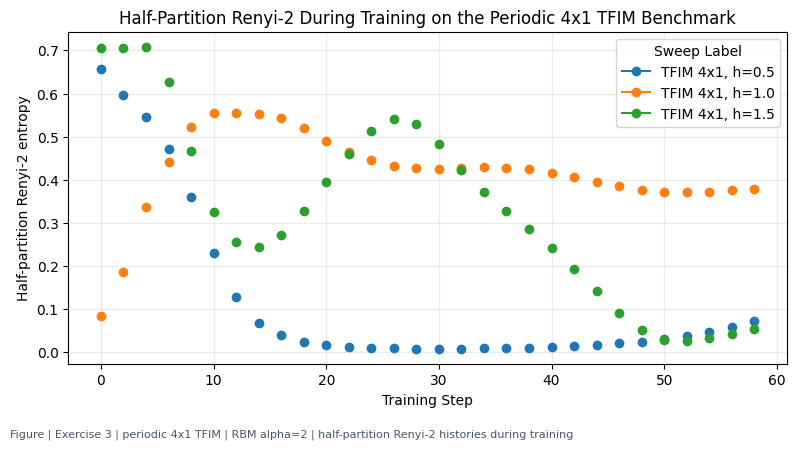

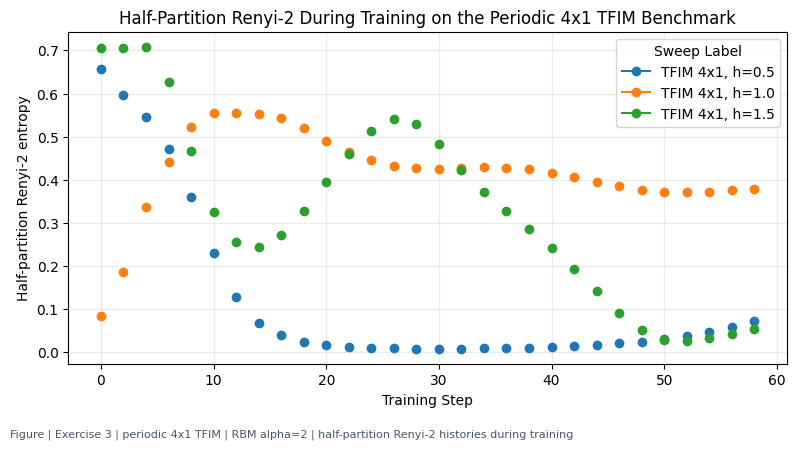

In [12]:
small_entropy_figure = plot_training_history(
    exercise_3_small_history,
    'renyi2_entropy',
    line_column='sweep_label',
    title='Half-Partition Renyi-2 During Training on the Periodic 4x1 TFIM Benchmark',
)
add_report_figure_context(
    small_entropy_figure,
    distinction='Figure',
    context='Exercise 3 | periodic 4x1 TFIM | RBM alpha=2 | half-partition Renyi-2 histories during training',
)
small_entropy_figure


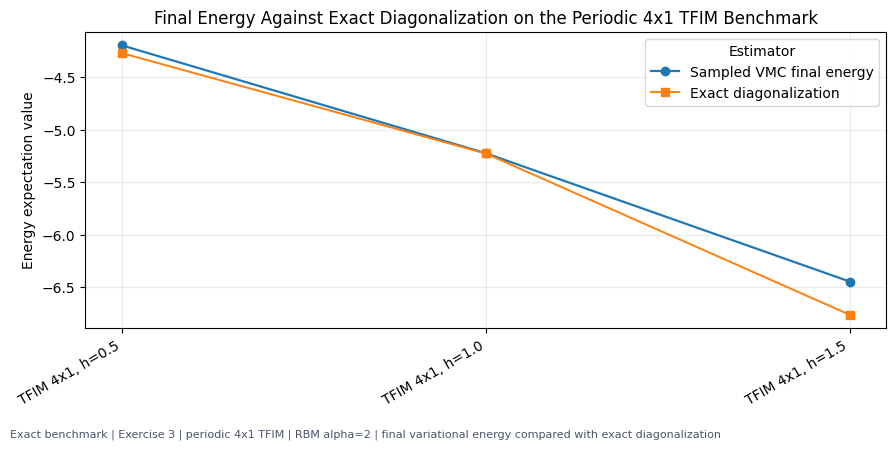

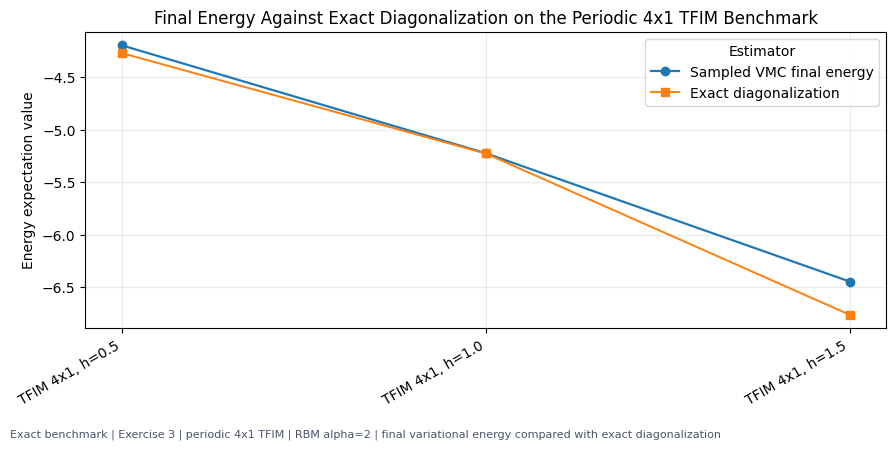

In [13]:
small_benchmark_figure = plot_energy_benchmark(
    exercise_3_small_summary,
    title='Final Energy Against Exact Diagonalization on the Periodic 4x1 TFIM Benchmark',
)
add_report_figure_context(
    small_benchmark_figure,
    distinction='Exact benchmark',
    context='Exercise 3 | periodic 4x1 TFIM | RBM alpha=2 | final variational energy compared with exact diagonalization',
)
small_benchmark_figure


In [14]:
exercise_3_small_diagnostics[[
    'sweep_label',
    'initial_energy',
    'final_energy',
    'energy_error',
    'exact_half_partition_renyi2',
    'final_half_partition_renyi2',
    'tail_energy_std',
]].round(6)

,sweep_label,initial_energy,final_energy,energy_error,exact_half_partition_renyi2,final_half_partition_renyi2,tail_energy_std
0,"TFIM 4x1, h=0.5",-1.089076,-4.197760,0.073798,0.659281,0.078455,0.003395
1,"TFIM 4x1, h=1.0",-2.762544,-5.223773,0.002479,0.386461,0.381652,0.000435
2,"TFIM 4x1, h=1.5",3.435036,-6.443930,0.316079,0.167198,0.059769,0.023170


The small-system benchmark is meant to separate three regimes with one exact periodic-chain reference.

- The `h = 0.5` ferromagnetic run should probe the ordered side of the TFIM and provides the low-field comparison point requested for Problem 3(c).
- The `h = 1.0` run remains the critical benchmark, where optimization difficulty and entanglement are expected to be enhanced relative to the gapped phases.
- The `h = 1.5` run provides the off-critical paramagnetic comparison on the disordered side.

After execution, the benchmark should be read through the ordering of the final energy errors, the stability of the energy traces, and the half-partition Renyi-2 trajectories across these three field values.


## 3/d Larger-System Periodic-System Study

The larger-system section is split into separate periodic TFIM and periodic `J_1-J_2` cells so each workflow can be run and rerun independently.

The retained systems are:

- a periodic length-32 TFIM chain at `h = 1.0` and `1.5`
- a periodic `5x5` TFIM lattice at `h = 3.0` and `4.0`
- a periodic `5x5` square-lattice `J_1-J_2` model at `J_1/J_2 = 1.8` and `2.2`

Exact energies and exact entanglement references remain disabled in this section because these runs are intended as sampled-VMC large-system benchmarks.


### Lattice Visualizations

The three benchmark geometries used in the larger-system study are shown explicitly below. For visual clarity, the two square-lattice graphs are drawn with open boundaries even though the Hamiltonians in the actual simulations use periodic boundary conditions. The one-dimensional chain is drawn with periodic boundaries because the ring geometry remains visually clear at this size. Blue edges denote nearest-neighbor couplings, and the frustrated `J_1-J_2` lattice adds red diagonal second-neighbor bonds.


In [ ]:
tfim_chain_visual_graph = Chain1D(12, pbc=True)
tfim_chain_visual_figure = plot_lattice_graph(
    tfim_chain_visual_graph,
    title='Periodic TFIM Chain (L = 12)',
    edge_specs={1: '#2563EB'},
    legend_entries=[('#2563EB', 'Nearest-neighbor Ising bond')],
    figsize=(4.6, 4.6),
)

tfim_square_visual_graph = SquareLattice(5, 5, pbc=False)
tfim_square_visual_figure = plot_lattice_graph(
    tfim_square_visual_graph,
    title='TFIM Lattice (5x5)',
    edge_specs={1: '#2563EB'},
    legend_entries=[('#2563EB', 'Nearest-neighbor Ising bond')],
)

j1j2_square_visual_graph = SquareLattice(5, 5, pbc=False)
j1j2_square_visual_figure = plot_lattice_graph(
    j1j2_square_visual_graph,
    title='J1-J2 Lattice (5x5)',
    edge_specs={1: '#2563EB', 2: '#DC2626'},
    legend_entries=[
        ('#2563EB', 'J1 nearest-neighbor bond'),
        ('#DC2626', 'J2 diagonal bond'),
    ],
    legend_columns=2,
)

display(tfim_chain_visual_figure)
display(tfim_square_visual_figure)
display(j1j2_square_visual_figure)


In [15]:
exercise_3_large_tfim_points = [
    {
        'label': 'TFIM 1D L=32, h=1.0',
        'hamiltonian': 'tfim',
        'lattice_shape': (32, 1),
        'pbc': True,
        'J': 1.0,
        'h': 1.0,
    },
    {
        'label': 'TFIM 1D L=32, h=1.5',
        'hamiltonian': 'tfim',
        'lattice_shape': (32, 1),
        'pbc': True,
        'J': 1.0,
        'h': 1.5,
    },
    {
        'label': 'TFIM 5x5, h=3.0',
        'hamiltonian': 'tfim',
        'lattice_shape': (5, 5),
        'pbc': True,
        'J': 1.0,
        'h': 3.0,
    },
    {
        'label': 'TFIM 5x5, h=4.0',
        'hamiltonian': 'tfim',
        'lattice_shape': (5, 5),
        'pbc': True,
        'J': 1.0,
        'h': 4.0,
    },
]

exercise_3_large_tfim = run_hamiltonian_system_size_sweep(
    sweep_points=exercise_3_large_tfim_points,
    entropy_n_independent_runs=8,
    entropy_force_sampled=True,
    compute_exact=False,
    **selected_model,
    **large_training_config,
)

exercise_3_large_tfim_summary = exercise_3_large_tfim['summary_table'].copy().round(6)
exercise_3_large_tfim_diagnostics = (
    pd.DataFrame([
        training_diagnostics_row(
            sweep_result['label'],
            sweep_result,
            field_h=float(sweep_result['couplings']['h']) if not np.isnan(sweep_result['couplings']['h']) else None,
            J1=float(sweep_result['couplings']['J1']) if not np.isnan(sweep_result['couplings']['J1']) else None,
            J2=float(sweep_result['couplings']['J2']) if not np.isnan(sweep_result['couplings']['J2']) else None,
        )
        for sweep_result in exercise_3_large_tfim['sweep_results']
    ])
    .sort_values(['n_sites', 'sweep_label'])
    .reset_index(drop=True)
    .round(6)
)

exercise_3_large_tfim_summary[[
    'sweep_label',
    'hamiltonian',
    'lattice_shape',
    'n_sites',
    'final_energy',
    'energy_error',
    'final_renyi2_entropy',
]]


,sweep_label,hamiltonian,lattice_shape,n_sites,final_energy,energy_error,final_renyi2_entropy
0,"TFIM 5x5, h=3.0",tfim,"(5, 5)",25,-42.979151,NaN,0.221975
1,"TFIM 5x5, h=4.0",tfim,"(5, 5)",25,-49.251486,NaN,3.054304
2,"TFIM 1D L=32, h=1.0",tfim,"(32, 1)",32,-27.779286,NaN,1.266810
3,"TFIM 1D L=32, h=1.5",tfim,"(32, 1)",32,-13.777831,NaN,0.859072


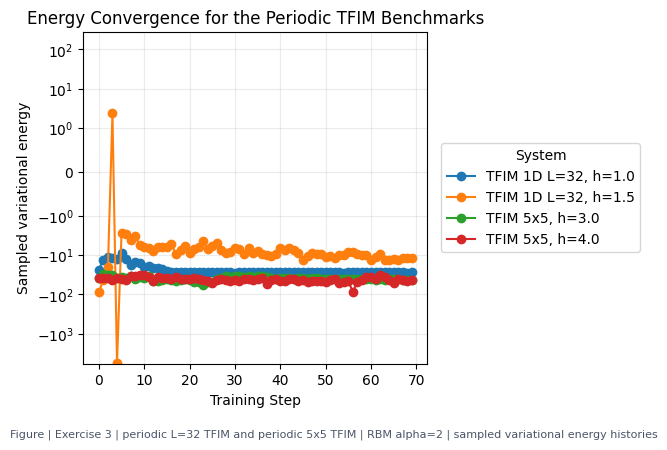

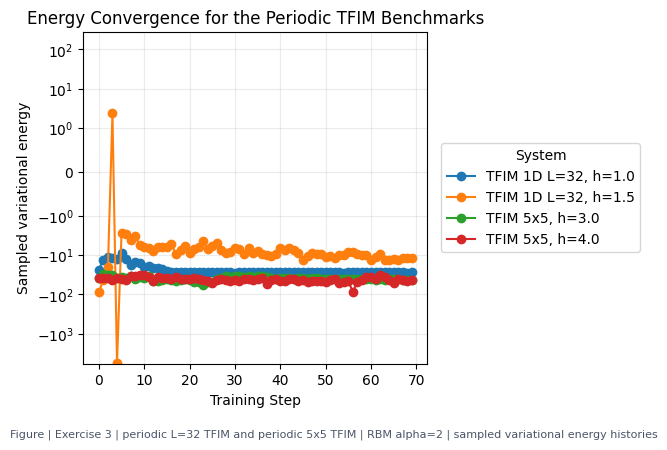

In [16]:
large_tfim_energy_history_figure = plot_training_history(
    exercise_3_large_tfim['training_history_table'],
    'energy',
    line_column='sweep_label',
    title='Energy Convergence for the Periodic TFIM Benchmarks',
)
large_tfim_energy_axis = large_tfim_energy_history_figure.axes[0]
large_tfim_energy_axis.set_yscale('symlog', linthresh=1.0)
large_tfim_energy_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_tfim_energy_history_figure,
    distinction='Figure',
    context='Exercise 3 | periodic L=32 TFIM and periodic 5x5 TFIM | RBM alpha=2 | sampled variational energy histories',
)
large_tfim_energy_history_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_tfim_energy_history_figure


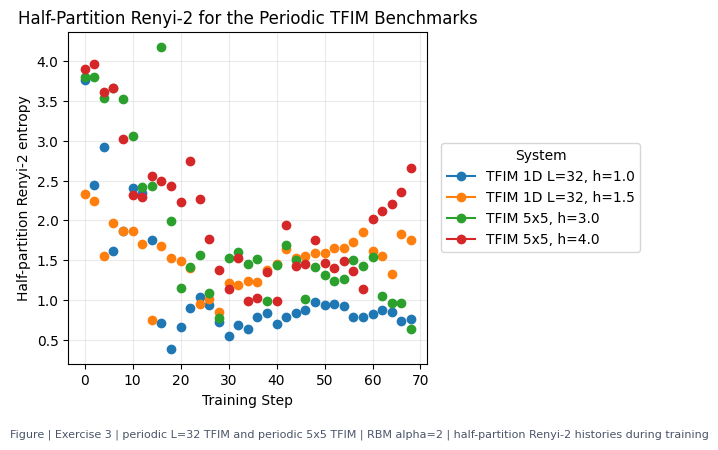

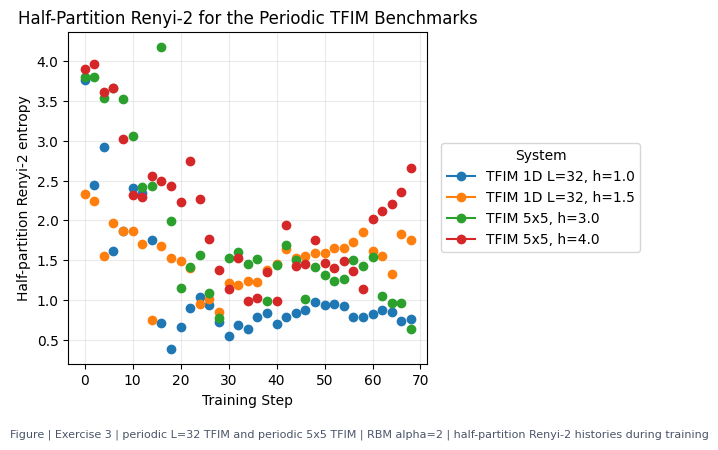

In [17]:
large_tfim_entropy_history_figure = plot_training_history(
    exercise_3_large_tfim['training_history_table'],
    'renyi2_entropy',
    line_column='sweep_label',
    title='Half-Partition Renyi-2 for the Periodic TFIM Benchmarks',
)
large_tfim_entropy_axis = large_tfim_entropy_history_figure.axes[0]
large_tfim_entropy_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_tfim_entropy_history_figure,
    distinction='Figure',
    context='Exercise 3 | periodic L=32 TFIM and periodic 5x5 TFIM | RBM alpha=2 | half-partition Renyi-2 histories during training',
)
large_tfim_entropy_history_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_tfim_entropy_history_figure


In [18]:
exercise_3_large_j1j2_points = [
    {
        'label': 'J1-J2 5x5, J1/J2=1.8',
        'hamiltonian': 'j1_j2',
        'lattice_shape': (5, 5),
        'pbc': True,
        'J1': 1.8,
        'J2': 1.0,
    },
    {
        'label': 'J1-J2 5x5, J1/J2=2.2',
        'hamiltonian': 'j1_j2',
        'lattice_shape': (5, 5),
        'pbc': True,
        'J1': 2.2,
        'J2': 1.0,
    },
]

exercise_3_large_j1j2 = run_hamiltonian_system_size_sweep(
    sweep_points=exercise_3_large_j1j2_points,
    entropy_n_independent_runs=8,
    entropy_force_sampled=True,
    compute_exact=False,
    **selected_model,
    **large_training_config,
)

exercise_3_large_j1j2_summary = exercise_3_large_j1j2['summary_table'].copy().round(6)
exercise_3_large_j1j2_diagnostics = (
    pd.DataFrame([
        training_diagnostics_row(
            sweep_result['label'],
            sweep_result,
            field_h=float(sweep_result['couplings']['h']) if not np.isnan(sweep_result['couplings']['h']) else None,
            J1=float(sweep_result['couplings']['J1']) if not np.isnan(sweep_result['couplings']['J1']) else None,
            J2=float(sweep_result['couplings']['J2']) if not np.isnan(sweep_result['couplings']['J2']) else None,
        )
        for sweep_result in exercise_3_large_j1j2['sweep_results']
    ])
    .sort_values(['n_sites', 'sweep_label'])
    .reset_index(drop=True)
    .round(6)
)

exercise_3_large_j1j2_summary[[
    'sweep_label',
    'hamiltonian',
    'lattice_shape',
    'n_sites',
    'final_energy',
    'energy_error',
    'final_renyi2_entropy',
]]


,sweep_label,hamiltonian,lattice_shape,n_sites,final_energy,energy_error,final_renyi2_entropy
0,"J1-J2 5x5, J1/J2=1.8",j1_j2,"(5, 5)",25,-11.999737,NaN,0.979289
1,"J1-J2 5x5, J1/J2=2.2",j1_j2,"(5, 5)",25,-27.194943,NaN,0.285725


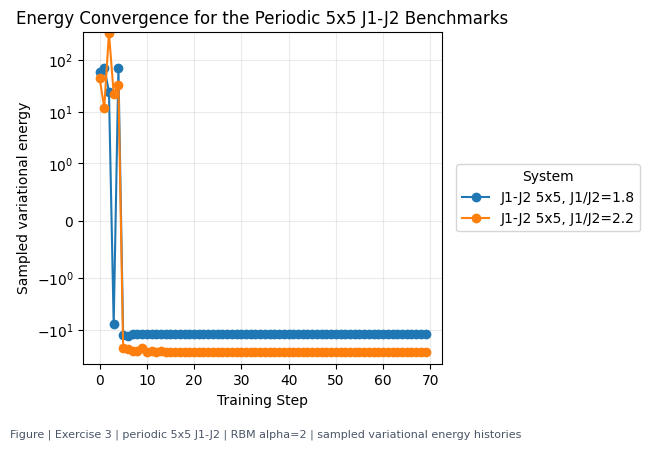

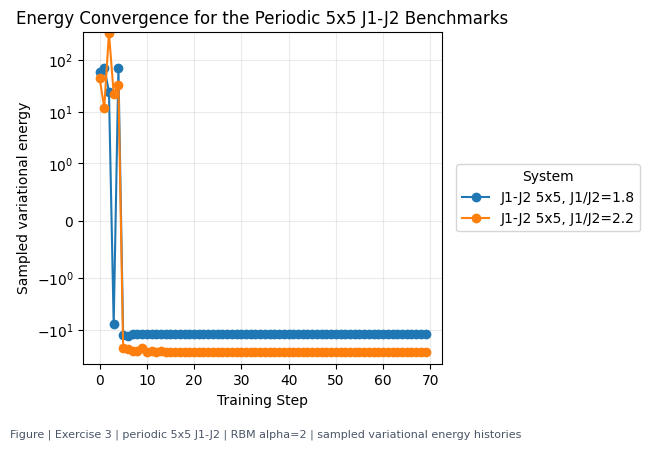

In [19]:
large_j1j2_energy_history_figure = plot_training_history(
    exercise_3_large_j1j2['training_history_table'],
    'energy',
    line_column='sweep_label',
    title='Energy Convergence for the Periodic 5x5 J1-J2 Benchmarks',
)
large_j1j2_energy_axis = large_j1j2_energy_history_figure.axes[0]
large_j1j2_energy_axis.set_yscale('symlog', linthresh=1.0)
large_j1j2_energy_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_j1j2_energy_history_figure,
    distinction='Figure',
    context='Exercise 3 | periodic 5x5 J1-J2 | RBM alpha=2 | sampled variational energy histories',
)
large_j1j2_energy_history_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_j1j2_energy_history_figure


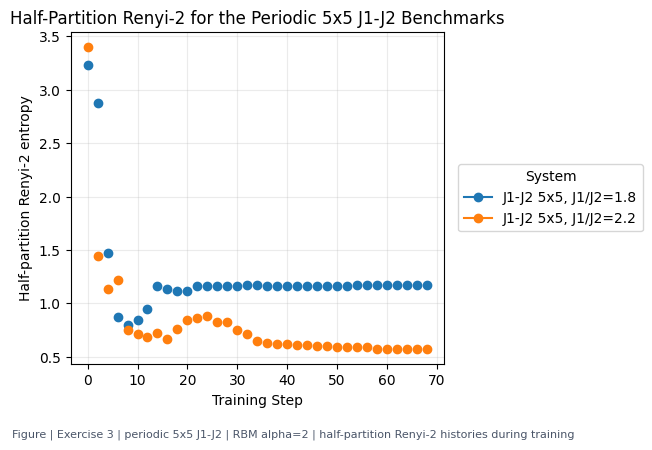

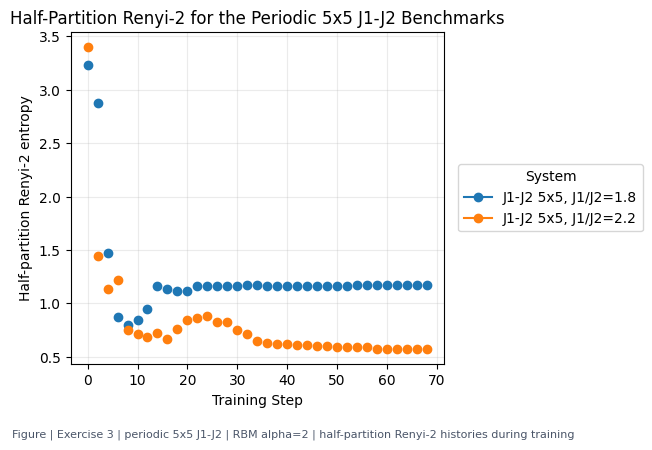

In [20]:
large_j1j2_entropy_history_figure = plot_training_history(
    exercise_3_large_j1j2['training_history_table'],
    'renyi2_entropy',
    line_column='sweep_label',
    title='Half-Partition Renyi-2 for the Periodic 5x5 J1-J2 Benchmarks',
)
large_j1j2_entropy_axis = large_j1j2_entropy_history_figure.axes[0]
large_j1j2_entropy_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_j1j2_entropy_history_figure,
    distinction='Figure',
    context='Exercise 3 | periodic 5x5 J1-J2 | RBM alpha=2 | half-partition Renyi-2 histories during training',
)
large_j1j2_entropy_history_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_j1j2_entropy_history_figure


In [21]:
exercise_3_large = {
    'sweep_results': exercise_3_large_tfim['sweep_results'] + exercise_3_large_j1j2['sweep_results'],
    'training_history_table': pd.concat([
        exercise_3_large_tfim['training_history_table'],
        exercise_3_large_j1j2['training_history_table'],
    ], ignore_index=True),
}

exercise_3_large_summary = (
    pd.concat([
        exercise_3_large_tfim_summary,
        exercise_3_large_j1j2_summary,
    ], ignore_index=True)
    .sort_values(['n_sites', 'sweep_label'])
    .reset_index(drop=True)
    .round(6)
)

exercise_3_large_diagnostics = (
    pd.concat([
        exercise_3_large_tfim_diagnostics,
        exercise_3_large_j1j2_diagnostics,
    ], ignore_index=True)
    .sort_values(['n_sites', 'sweep_label'])
    .reset_index(drop=True)
    .round(6)
)

exercise_3_large_entropy_scan = pd.concat([
    sweep_result['entropy_scan_table'].assign(sweep_label=sweep_result['label'])
    for sweep_result in exercise_3_large['sweep_results']
], ignore_index=True)

exercise_3_large_summary[[
    'sweep_label',
    'hamiltonian',
    'lattice_shape',
    'n_sites',
    'final_energy',
    'energy_error',
    'final_renyi2_entropy',
]]


,sweep_label,hamiltonian,lattice_shape,n_sites,final_energy,energy_error,final_renyi2_entropy
0,"J1-J2 5x5, J1/J2=1.8",j1_j2,"(5, 5)",25,-11.999737,NaN,0.979289
1,"J1-J2 5x5, J1/J2=2.2",j1_j2,"(5, 5)",25,-27.194943,NaN,0.285725
2,"TFIM 5x5, h=3.0",tfim,"(5, 5)",25,-42.979151,NaN,0.221975
3,"TFIM 5x5, h=4.0",tfim,"(5, 5)",25,-49.251486,NaN,3.054304
4,"TFIM 1D L=32, h=1.0",tfim,"(32, 1)",32,-27.779286,NaN,1.266810
5,"TFIM 1D L=32, h=1.5",tfim,"(32, 1)",32,-13.777831,NaN,0.859072


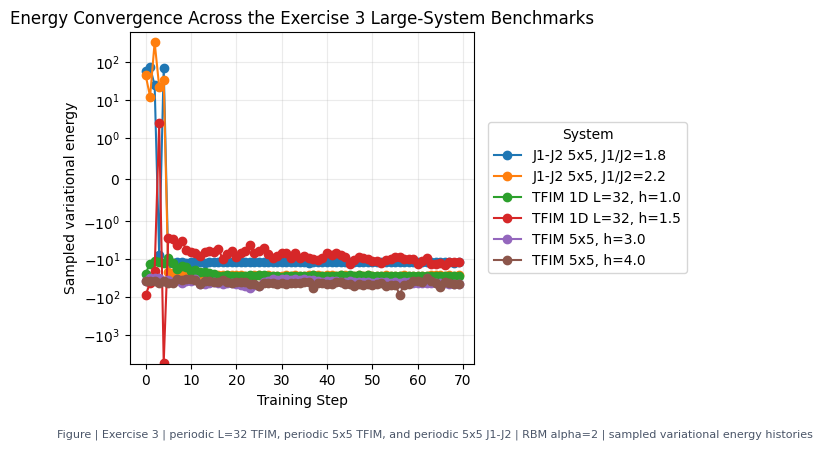

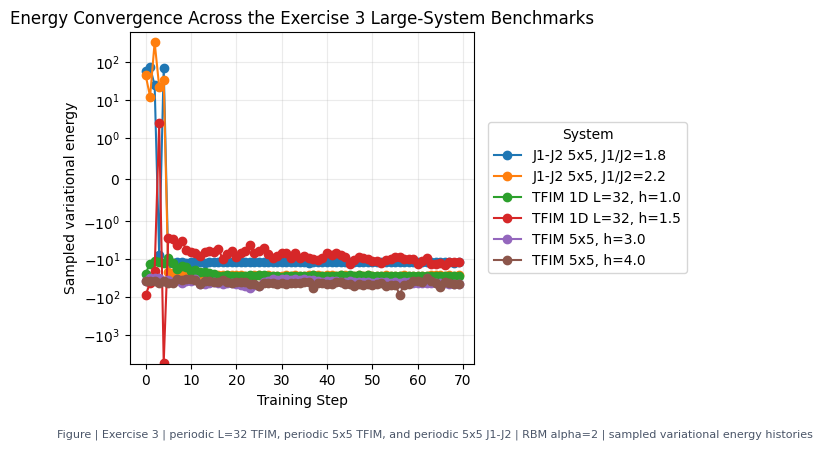

In [22]:
large_energy_history_figure = plot_training_history(
    exercise_3_large['training_history_table'],
    'energy',
    line_column='sweep_label',
    title='Energy Convergence Across the Exercise 3 Large-System Benchmarks',
)
large_energy_axis = large_energy_history_figure.axes[0]
large_energy_axis.set_yscale('symlog', linthresh=1.0)
large_energy_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_energy_history_figure,
    distinction='Figure',
    context='Exercise 3 | periodic L=32 TFIM, periodic 5x5 TFIM, and periodic 5x5 J1-J2 | RBM alpha=2 | sampled variational energy histories',
)
large_energy_history_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_energy_history_figure


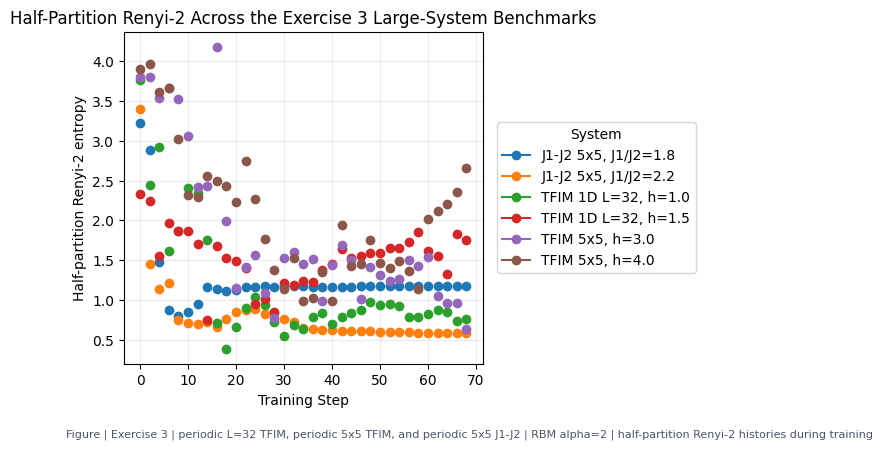

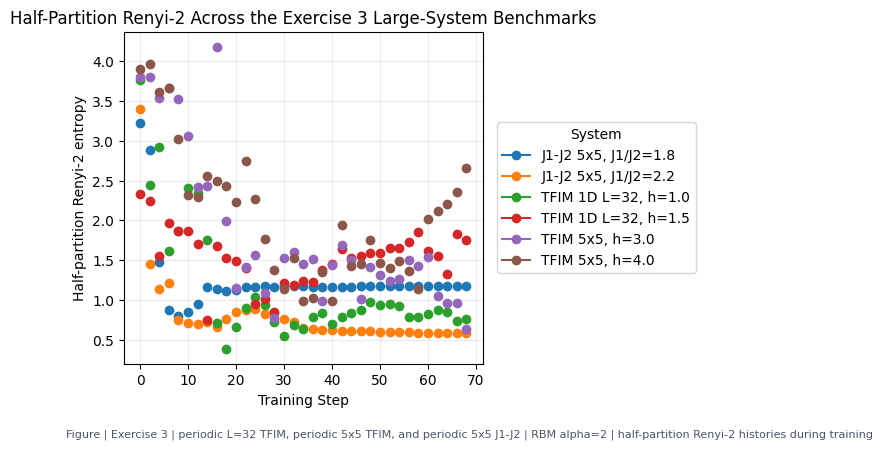

In [23]:
large_entropy_history_figure = plot_training_history(
    exercise_3_large['training_history_table'],
    'renyi2_entropy',
    line_column='sweep_label',
    title='Half-Partition Renyi-2 Across the Exercise 3 Large-System Benchmarks',
)
large_entropy_axis = large_entropy_history_figure.axes[0]
large_entropy_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_entropy_history_figure,
    distinction='Figure',
    context='Exercise 3 | periodic L=32 TFIM, periodic 5x5 TFIM, and periodic 5x5 J1-J2 | RBM alpha=2 | half-partition Renyi-2 histories during training',
)
large_entropy_history_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_entropy_history_figure


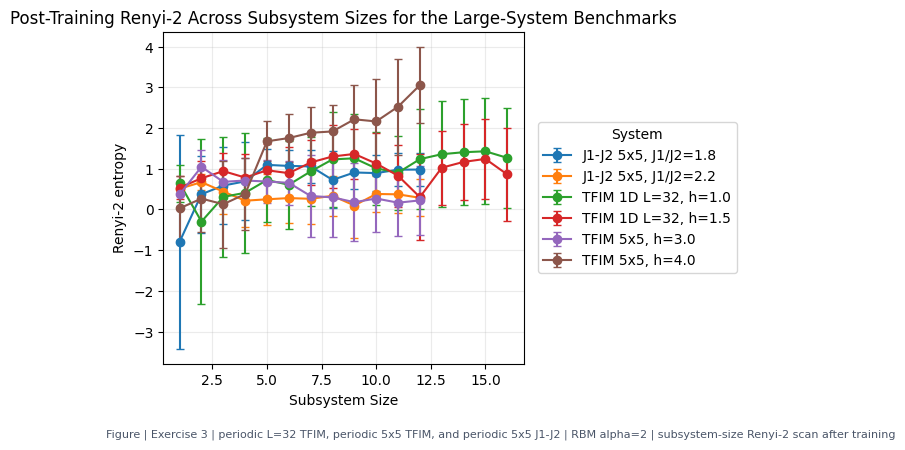

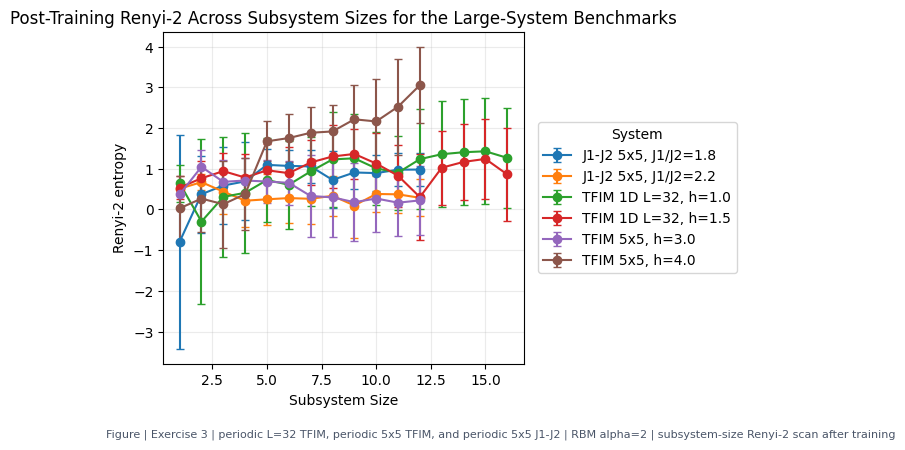

In [24]:
large_entropy_scan_figure = plot_entropy_scan(
    exercise_3_large_entropy_scan,
    line_column='sweep_label',
    title='Post-Training Renyi-2 Across Subsystem Sizes for the Large-System Benchmarks',
)
large_entropy_scan_axis = large_entropy_scan_figure.axes[0]
large_entropy_scan_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    large_entropy_scan_figure,
    distinction='Figure',
    context='Exercise 3 | periodic L=32 TFIM, periodic 5x5 TFIM, and periodic 5x5 J1-J2 | RBM alpha=2 | subsystem-size Renyi-2 scan after training',
)
large_entropy_scan_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
large_entropy_scan_figure


In [25]:
exercise_3_large_diagnostics[[
    'sweep_label',
    'n_sites',
    'energy_error',
    'energy_error_per_site',
    'final_half_partition_renyi2',
    'tail_energy_std',
]].round(6)


,sweep_label,n_sites,energy_error,energy_error_per_site,final_half_partition_renyi2,tail_energy_std
0,"J1-J2 5x5, J1/J2=1.8",25,NaN,NaN,0.979289,0.114004
1,"J1-J2 5x5, J1/J2=2.2",25,NaN,NaN,0.285725,0.165600
2,"TFIM 5x5, h=3.0",25,NaN,NaN,0.221975,1.382138
3,"TFIM 5x5, h=4.0",25,NaN,NaN,3.054304,4.485543
4,"TFIM 1D L=32, h=1.0",32,NaN,NaN,1.266810,0.471005
5,"TFIM 1D L=32, h=1.5",32,NaN,NaN,0.859072,0.740313


The larger-system section is split so the periodic TFIM and periodic `J_1-J_2` workflows can be run and rerun independently.

- The periodic length-32 TFIM chain remains in the sweep.
- The periodic two-dimensional TFIM benchmarks now use `h = 3.0` and `4.0`, so the retained fields are aligned with the square-lattice critical scale.
- The periodic `J_1-J_2` benchmarks now use `J_1/J_2 = 1.8` and `2.2`, which places the comparison in the standard frustrated regime near `J_2/J_1 pprox 0.5`.
- After both subcells complete, the notebook merges them into one combined summary table, diagnostics table, history table, and entropy scan.
- Exact-reference columns remain disabled throughout this section.


## 3/e GHZ Diagnostic On The Periodic Length-32 TFIM Chain

The GHZ appendix is redefined around the `h = 0` TFIM ground state on the periodic length-32 Ising chain. In that limit the target is the cat-like ferromagnetic ground-state manifold, so the appendix asks whether the retained RBM/VMC workflow can move toward the corresponding GHZ-like superposition on the same one-dimensional system class used in the main TFIM study.


In [26]:
ghz_config = {
    'lattice_shape': (32, 1),
    'n_iter': 20,
    'n_samples': 128,
    'n_discard_per_chain': 16,
    'n_chains': 16,
    'callback_every': 2,
}

exercise_3_ghz = run_ghz_bonus_workflow(
    **selected_model,
    **ghz_config,
)

exercise_3_ghz_history = exercise_3_ghz['history_df'].copy()
exercise_3_ghz_history['model'] = 'RBM_GHZ_chain32_h0'
ghz_metrics_table = pd.DataFrame([exercise_3_ghz['ghz_metrics']]).round(6)

ghz_metrics_table


,ghz_fidelity,cat_sector_weight,half_partition_renyi2,used_exact_statevector
0,NaN,NaN,-3.20976,0.0


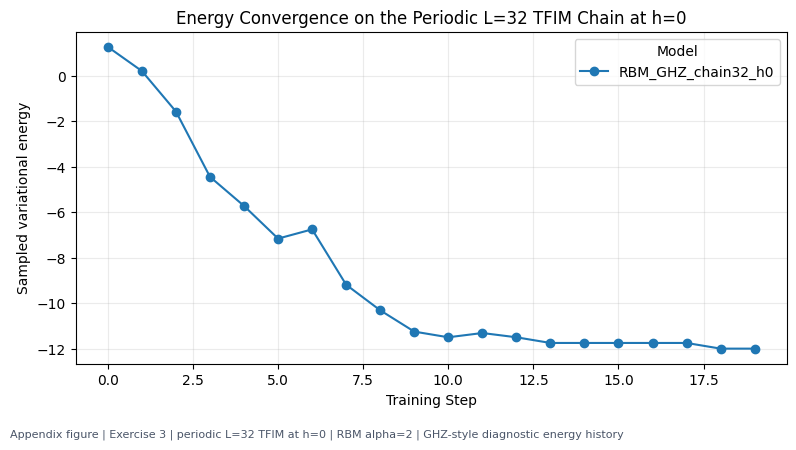

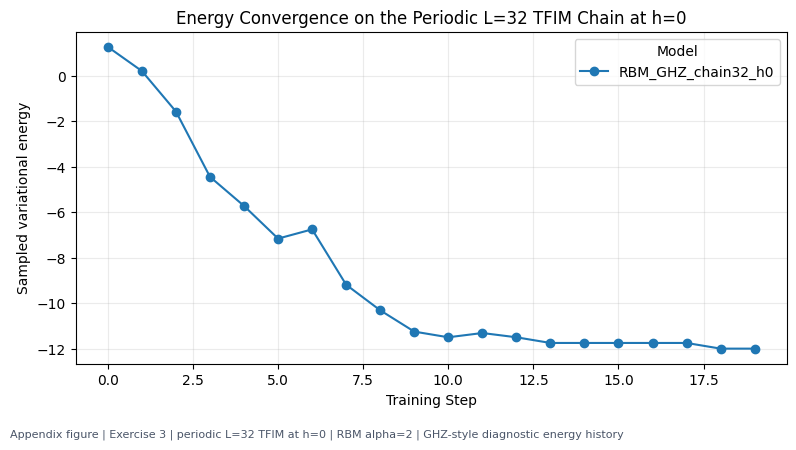

In [27]:
ghz_history_figure = plot_training_history(
    exercise_3_ghz_history,
    'energy',
    line_column='model',
    title='Energy Convergence on the Periodic L=32 TFIM Chain at h=0',
)
add_report_figure_context(
    ghz_history_figure,
    distinction='Appendix figure',
    context='Exercise 3 | periodic L=32 TFIM at h=0 | RBM alpha=2 | GHZ-style diagnostic energy history',
)
ghz_history_figure


The GHZ appendix remains a diagnostic rather than a completed benchmark. The target is now the periodic length-32 `h = 0` TFIM ground state, so the retained metrics should be read as evidence about cat-sector capture and GHZ fidelity on the main-chain geometry, not as a separate toy-model result.


## 3/f Tail-Sensitivity Appendix

The earlier exercises already support a narrow but useful claim. Exercise 2 showed that the sampled SWAP estimator reproduces exact small-system `S_2` well enough to use `S_2` as a coarse entanglement benchmark, and the periodic `4x1` Exercise 3 runs already show a stable ordering of energies and half-partition `S_2` across the ferromagnetic, critical, and paramagnetic regimes.

That still does not answer the tail question by itself. Renyi-2 is dominated by the larger eigenvalues of the reduced density matrix, so agreement in energy and `S_2` is necessary but not sufficient if the goal is to claim that the small Schmidt weights are also correct. The right place to demonstrate that limitation is therefore the exact small-system benchmark, where the full half-partition spectrum is still available.


In [28]:
def exact_tail_summary_row(label: str, result: dict[str, object], field_h: float) -> dict[str, float | str]:
    exact = result['exact']
    ground_state = np.asarray(exact['ground_state'], dtype=np.complex128)
    n_sites = int(result['system']['hilbert'].size)
    subsystem = tuple(range(n_sites // 2))
    spectrum = observables.entanglement_spectrum(ground_state, subsystem=subsystem)
    s1 = observables.von_neumann_entropy(ground_state, subsystem=subsystem)
    s2 = observables.renyi_entropy_from_statevector(ground_state, subsystem=subsystem, alpha=2.0)
    cumulative = np.cumsum(spectrum)
    top2_index = min(1, len(cumulative) - 1)
    top4_index = min(3, len(cumulative) - 1)
    return {
        'sweep_label': label,
        'field_h': float(field_h),
        'exact_von_neumann': float(s1),
        'exact_renyi2': float(s2),
        's1_minus_s2': float(s1 - s2),
        'leading_weight': float(spectrum[0]),
        'top2_cumulative_weight': float(cumulative[top2_index]),
        'tail_weight_after_top2': float(max(0.0, 1.0 - cumulative[top2_index])),
        'tail_weight_after_top4': float(max(0.0, 1.0 - cumulative[top4_index])),
        'spectrum_rank': int(np.count_nonzero(spectrum > 1e-12)),
    }


def exact_tail_spectrum_rows(label: str, result: dict[str, object], field_h: float) -> pd.DataFrame:
    exact = result['exact']
    ground_state = np.asarray(exact['ground_state'], dtype=np.complex128)
    n_sites = int(result['system']['hilbert'].size)
    subsystem = tuple(range(n_sites // 2))
    spectrum = observables.entanglement_spectrum(ground_state, subsystem=subsystem)
    cumulative = np.cumsum(spectrum)
    return pd.DataFrame({
        'sweep_label': label,
        'field_h': float(field_h),
        'level': np.arange(1, len(spectrum) + 1, dtype=np.int64),
        'weight': spectrum,
        'cumulative_weight': cumulative,
        'entanglement_energy': -np.log(np.clip(spectrum, 1e-15, None)),
    })


exercise_3_tail_support = (
    exercise_3_small_summary[[
        'sweep_label',
        'field_h',
        'exact_ground_energy',
        'final_energy',
        'energy_error',
        'exact_half_partition_renyi2',
        'final_half_partition_renyi2',
        'half_partition_renyi2_gap',
    ]]
    .sort_values('field_h')
    .reset_index(drop=True)
)

exercise_3_tail_summary = pd.DataFrame([
    exact_tail_summary_row('TFIM 4x1, h=0.5', exercise_3_small_ferromagnetic, 0.5),
    exact_tail_summary_row('TFIM 4x1, h=1.0', exercise_3_small_critical, 1.0),
    exact_tail_summary_row('TFIM 4x1, h=1.5', exercise_3_small_paramagnetic, 1.5),
]).sort_values('field_h').reset_index(drop=True).round(6)

exercise_3_tail_spectrum = pd.concat([
    exact_tail_spectrum_rows('TFIM 4x1, h=0.5', exercise_3_small_ferromagnetic, 0.5),
    exact_tail_spectrum_rows('TFIM 4x1, h=1.0', exercise_3_small_critical, 1.0),
    exact_tail_spectrum_rows('TFIM 4x1, h=1.5', exercise_3_small_paramagnetic, 1.5),
], ignore_index=True)

exercise_3_tail_support


,sweep_label,field_h,exact_ground_energy,final_energy,energy_error,exact_half_partition_renyi2,final_half_partition_renyi2,half_partition_renyi2_gap
0,"TFIM 4x1, h=0.5",0.5,-4.271558,-4.197760,0.073798,0.659281,0.078455,-0.580827
1,"TFIM 4x1, h=1.0",1.0,-5.226252,-5.223773,0.002479,0.386461,0.381652,-0.004808
2,"TFIM 4x1, h=1.5",1.5,-6.760009,-6.443930,0.316079,0.167198,0.059769,-0.107429


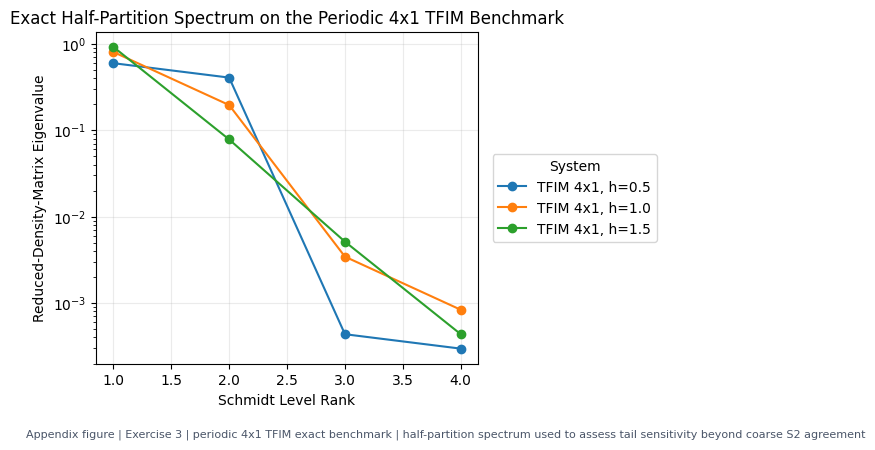

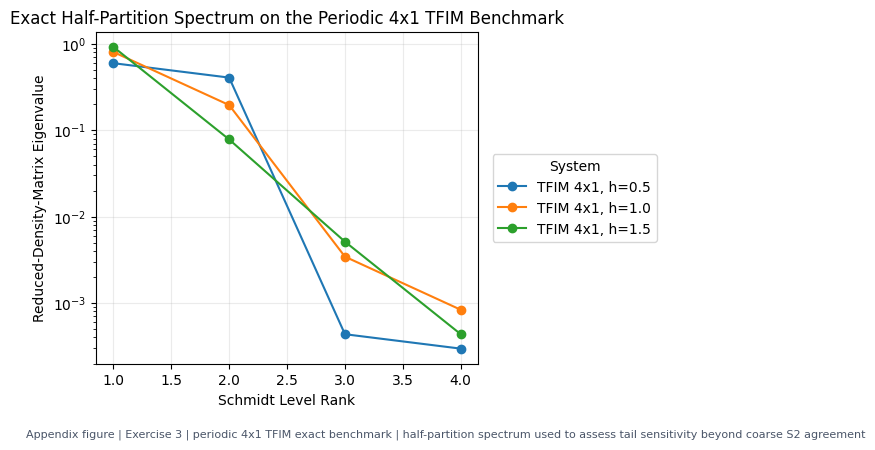

In [29]:
tail_spectrum_figure, tail_axis = plt.subplots(figsize=(8, 4.5))
for label, group in exercise_3_tail_spectrum.groupby('sweep_label'):
    tail_axis.semilogy(group['level'], group['weight'], marker='o', label=str(label))

tail_axis.set_xlabel('Schmidt Level Rank')
tail_axis.set_ylabel('Reduced-Density-Matrix Eigenvalue')
tail_axis.set_title('Exact Half-Partition Spectrum on the Periodic 4x1 TFIM Benchmark')
tail_axis.grid(alpha=0.25)
tail_axis.legend(title='System', loc='center left', bbox_to_anchor=(1.02, 0.5))
add_report_figure_context(
    tail_spectrum_figure,
    distinction='Appendix figure',
    context='Exercise 3 | periodic 4x1 TFIM exact benchmark | half-partition spectrum used to assess tail sensitivity beyond coarse S2 agreement',
)
tail_spectrum_figure.tight_layout(rect=(0.0, 0.05, 0.82, 1.0))
tail_spectrum_figure


In [30]:
exercise_3_tail_summary


,sweep_label,field_h,exact_von_neumann,exact_renyi2,s1_minus_s2,leading_weight,top2_cumulative_weight,tail_weight_after_top2,tail_weight_after_top4,spectrum_rank
0,"TFIM 4x1, h=0.5",0.5,0.681084,0.659281,0.021803,0.594386,0.999266,0.000734,0.0,4
1,"TFIM 4x1, h=1.0",1.0,0.521869,0.386461,0.135408,0.800940,0.995722,0.004278,0.0,4
2,"TFIM 4x1, h=1.5",1.5,0.309274,0.167198,0.142076,0.916476,0.994434,0.005566,0.0,4


The exact spectrum makes the tail argument concrete.

- The Exercise 3 small benchmark already supports the coarse statement: energy errors remain controlled and the exact-versus-final half-partition `S_2` comparison preserves the expected ordering across `h = 0.5`, `1.0`, and `1.5`.
- The exact spectrum table and figure show why that is not yet a tail-faithfulness result. `S_1` is larger than `S_2` for all three exact ground states because `S_1` is more sensitive to the many smaller eigenvalues of the reduced density matrix.
- The critical `h = 1.0` case also carries the broadest visible spectrum and the largest post-top-two tail weight, which is consistent with the earlier exact and sampled evidence that criticality increases entanglement.

The conservative conclusion is therefore the intended one: the present workflow is well supported as a coarse entanglement benchmark, but the existing `S_2` agreement alone is not enough to claim that the tail of the entanglement spectrum is reproduced faithfully.


## Final Conclusions

The notebook is now structured to answer the revised Exercise 3 scope while keeping the large-system benchmarking layout publication-ready.

- **3(a)**: carry forward `RBM(alpha=2)` and make the activation-function choice explicit, including the shared `tanh`-bounded phase parameterization.
- **3(b)**: keep one common periodic-boundary VMC workflow across all systems.
- **3(c)**: benchmark the periodic `4x1` TFIM chain at `h = 0.5`, `1.0`, and `1.5`.
- **3(d)**: compare the periodic length-32 TFIM chain, the periodic `5x5` TFIM lattice at `h = 3.0` and `4.0`, and the periodic `5x5` `J_1-J_2` lattice at `J_1/J_2 = 1.8` and `2.2` with publication-ready labels and figures.
- **3(e)**: reinterpret the GHZ appendix as the `h = 0` periodic Ising-chain ground-state problem on the length-32 chain.
- **3(f)**: use the exact `4x1` benchmark spectrum to make a conservative tail-sensitivity claim: coarse `S_2` benchmarking is supported, but tail-faithfulness is not established by `S_2` alone.


## Limitations

The large-system section is still a sampled-VMC benchmark rather than an exact-reference study, so the presentation cleanup here should be read as figure polish rather than a change in scientific scope.

The new `3(f)` appendix is intentionally narrow. It is strong enough to justify a conservative statement about tail sensitivity on the exact small-system benchmark, but it does not by itself validate tail accuracy for the trained large-system NQS states.


## Export Exercise 3 Artifacts

Persist the main report tables and figures for later assembly.


In [31]:
architecture_evidence_paths = save_report_table(exercise_3_architecture_evidence, 'exercise_3_architecture_evidence', output_dir=exercise_output_dir)
architecture_decision_paths = save_report_table(exercise_3_architecture_decision, 'exercise_3_architecture_decision', output_dir=exercise_output_dir)
vmc_context_paths = save_report_table(exercise_3_vmc_context, 'exercise_3_vmc_context', output_dir=exercise_output_dir)
small_summary_paths = save_report_table(exercise_3_small_summary, 'exercise_3_small_summary', output_dir=exercise_output_dir)
small_diagnostics_paths = save_report_table(exercise_3_small_diagnostics, 'exercise_3_small_diagnostics', output_dir=exercise_output_dir)
small_history_paths = save_report_table(exercise_3_small_history, 'exercise_3_small_history', output_dir=exercise_output_dir)
large_tfim_summary_paths = save_report_table(exercise_3_large_tfim_summary, 'exercise_3_large_tfim_summary', output_dir=exercise_output_dir)
large_tfim_diagnostics_paths = save_report_table(exercise_3_large_tfim_diagnostics, 'exercise_3_large_tfim_diagnostics', output_dir=exercise_output_dir)
large_tfim_history_paths = save_report_table(exercise_3_large_tfim['training_history_table'], 'exercise_3_large_tfim_history', output_dir=exercise_output_dir)
large_j1j2_summary_paths = save_report_table(exercise_3_large_j1j2_summary, 'exercise_3_large_j1j2_summary', output_dir=exercise_output_dir)
large_j1j2_diagnostics_paths = save_report_table(exercise_3_large_j1j2_diagnostics, 'exercise_3_large_j1j2_diagnostics', output_dir=exercise_output_dir)
large_j1j2_history_paths = save_report_table(exercise_3_large_j1j2['training_history_table'], 'exercise_3_large_j1j2_history', output_dir=exercise_output_dir)
large_summary_paths = save_report_table(exercise_3_large_summary, 'exercise_3_large_summary', output_dir=exercise_output_dir)
large_diagnostics_paths = save_report_table(exercise_3_large_diagnostics, 'exercise_3_large_diagnostics', output_dir=exercise_output_dir)
large_history_paths = save_report_table(exercise_3_large['training_history_table'], 'exercise_3_large_history', output_dir=exercise_output_dir)
large_entropy_scan_paths = save_report_table(exercise_3_large_entropy_scan, 'exercise_3_large_entropy_scan', output_dir=exercise_output_dir)
ghz_paths = save_report_table(ghz_metrics_table, 'exercise_3_ghz_summary', output_dir=exercise_output_dir)
tail_support_paths = save_report_table(exercise_3_tail_support, 'exercise_3_tail_support', output_dir=exercise_output_dir)
tail_summary_paths = save_report_table(exercise_3_tail_summary, 'exercise_3_tail_summary', output_dir=exercise_output_dir)
tail_spectrum_paths = save_report_table(exercise_3_tail_spectrum, 'exercise_3_tail_spectrum', output_dir=exercise_output_dir)
architecture_summary_path = save_report_figure(architecture_summary_figure, 'exercise_3_architecture_summary', output_dir=exercise_output_dir)
tfim_chain_graph_path = save_report_figure(tfim_chain_visual_figure, 'exercise_3_tfim_chain_graph', output_dir=exercise_output_dir)
tfim_square_graph_path = save_report_figure(tfim_square_visual_figure, 'exercise_3_tfim_square_graph', output_dir=exercise_output_dir)
j1j2_square_graph_path = save_report_figure(j1j2_square_visual_figure, 'exercise_3_j1j2_square_graph', output_dir=exercise_output_dir)
small_energy_path = save_report_figure(small_energy_figure, 'exercise_3_small_energy', output_dir=exercise_output_dir)
small_entropy_path = save_report_figure(small_entropy_figure, 'exercise_3_small_entropy', output_dir=exercise_output_dir)
small_benchmark_path = save_report_figure(small_benchmark_figure, 'exercise_3_small_benchmark', output_dir=exercise_output_dir)
large_tfim_energy_path = save_report_figure(large_tfim_energy_history_figure, 'exercise_3_large_tfim_energy', output_dir=exercise_output_dir)
large_tfim_entropy_path = save_report_figure(large_tfim_entropy_history_figure, 'exercise_3_large_tfim_entropy', output_dir=exercise_output_dir)
large_j1j2_energy_path = save_report_figure(large_j1j2_energy_history_figure, 'exercise_3_large_j1j2_energy', output_dir=exercise_output_dir)
large_j1j2_entropy_path = save_report_figure(large_j1j2_entropy_history_figure, 'exercise_3_large_j1j2_entropy', output_dir=exercise_output_dir)
large_energy_path = save_report_figure(large_energy_history_figure, 'exercise_3_large_energy', output_dir=exercise_output_dir)
large_entropy_path = save_report_figure(large_entropy_history_figure, 'exercise_3_large_entropy', output_dir=exercise_output_dir)
large_entropy_scan_path = save_report_figure(large_entropy_scan_figure, 'exercise_3_large_entropy_scan', output_dir=exercise_output_dir)
ghz_history_path = save_report_figure(ghz_history_figure, 'exercise_3_ghz_history', output_dir=exercise_output_dir)
tail_spectrum_figure_path = save_report_figure(tail_spectrum_figure, 'exercise_3_tail_spectrum', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_3', 'name': 'architecture_decision', 'path': str(architecture_decision_paths['csv'])},
    {'section': 'exercise_3', 'name': 'architecture_evidence', 'path': str(architecture_evidence_paths['csv'])},
    {'section': 'exercise_3', 'name': 'architecture_summary_figure', 'path': str(architecture_summary_path)},
    {'section': 'exercise_3', 'name': 'tfim_chain_graph_figure', 'path': str(tfim_chain_graph_path)},
    {'section': 'exercise_3', 'name': 'tfim_square_graph_figure', 'path': str(tfim_square_graph_path)},
    {'section': 'exercise_3', 'name': 'j1j2_square_graph_figure', 'path': str(j1j2_square_graph_path)},
    {'section': 'exercise_3', 'name': 'ghz_history_figure', 'path': str(ghz_history_path)},
    {'section': 'exercise_3', 'name': 'ghz_summary', 'path': str(ghz_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_diagnostics', 'path': str(large_diagnostics_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_energy_figure', 'path': str(large_energy_path)},
    {'section': 'exercise_3', 'name': 'large_entropy_figure', 'path': str(large_entropy_path)},
    {'section': 'exercise_3', 'name': 'large_entropy_scan', 'path': str(large_entropy_scan_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_entropy_scan_figure', 'path': str(large_entropy_scan_path)},
    {'section': 'exercise_3', 'name': 'large_history', 'path': str(large_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_j1j2_diagnostics', 'path': str(large_j1j2_diagnostics_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_j1j2_energy_figure', 'path': str(large_j1j2_energy_path)},
    {'section': 'exercise_3', 'name': 'large_j1j2_entropy_figure', 'path': str(large_j1j2_entropy_path)},
    {'section': 'exercise_3', 'name': 'large_j1j2_history', 'path': str(large_j1j2_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_j1j2_summary', 'path': str(large_j1j2_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_summary', 'path': str(large_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_tfim_diagnostics', 'path': str(large_tfim_diagnostics_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_tfim_energy_figure', 'path': str(large_tfim_energy_path)},
    {'section': 'exercise_3', 'name': 'large_tfim_entropy_figure', 'path': str(large_tfim_entropy_path)},
    {'section': 'exercise_3', 'name': 'large_tfim_history', 'path': str(large_tfim_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_tfim_summary', 'path': str(large_tfim_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_benchmark_figure', 'path': str(small_benchmark_path)},
    {'section': 'exercise_3', 'name': 'small_diagnostics', 'path': str(small_diagnostics_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_energy_figure', 'path': str(small_energy_path)},
    {'section': 'exercise_3', 'name': 'small_entropy_figure', 'path': str(small_entropy_path)},
    {'section': 'exercise_3', 'name': 'small_history', 'path': str(small_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_summary', 'path': str(small_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'tail_spectrum', 'path': str(tail_spectrum_paths['csv'])},
    {'section': 'exercise_3', 'name': 'tail_spectrum_figure', 'path': str(tail_spectrum_figure_path)},
    {'section': 'exercise_3', 'name': 'tail_summary', 'path': str(tail_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'tail_support', 'path': str(tail_support_paths['csv'])},
    {'section': 'exercise_3', 'name': 'vmc_context', 'path': str(vmc_context_paths['csv'])},
])


,section,name,path
0,exercise_3,architecture_decision,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_3,architecture_evidence,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_3,architecture_summary_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_3,ghz_history_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_3,ghz_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
5,exercise_3,large_diagnostics,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
6,exercise_3,large_energy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
7,exercise_3,large_entropy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
8,exercise_3,large_entropy_scan,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
9,exercise_3,large_entropy_scan_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
